In [1]:
from exoatlas import * 
from exoatlas.visualizations import * 

In [2]:
e = TransitingExoplanets() 

Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt


Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-SolarSystem.txt


/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  sc

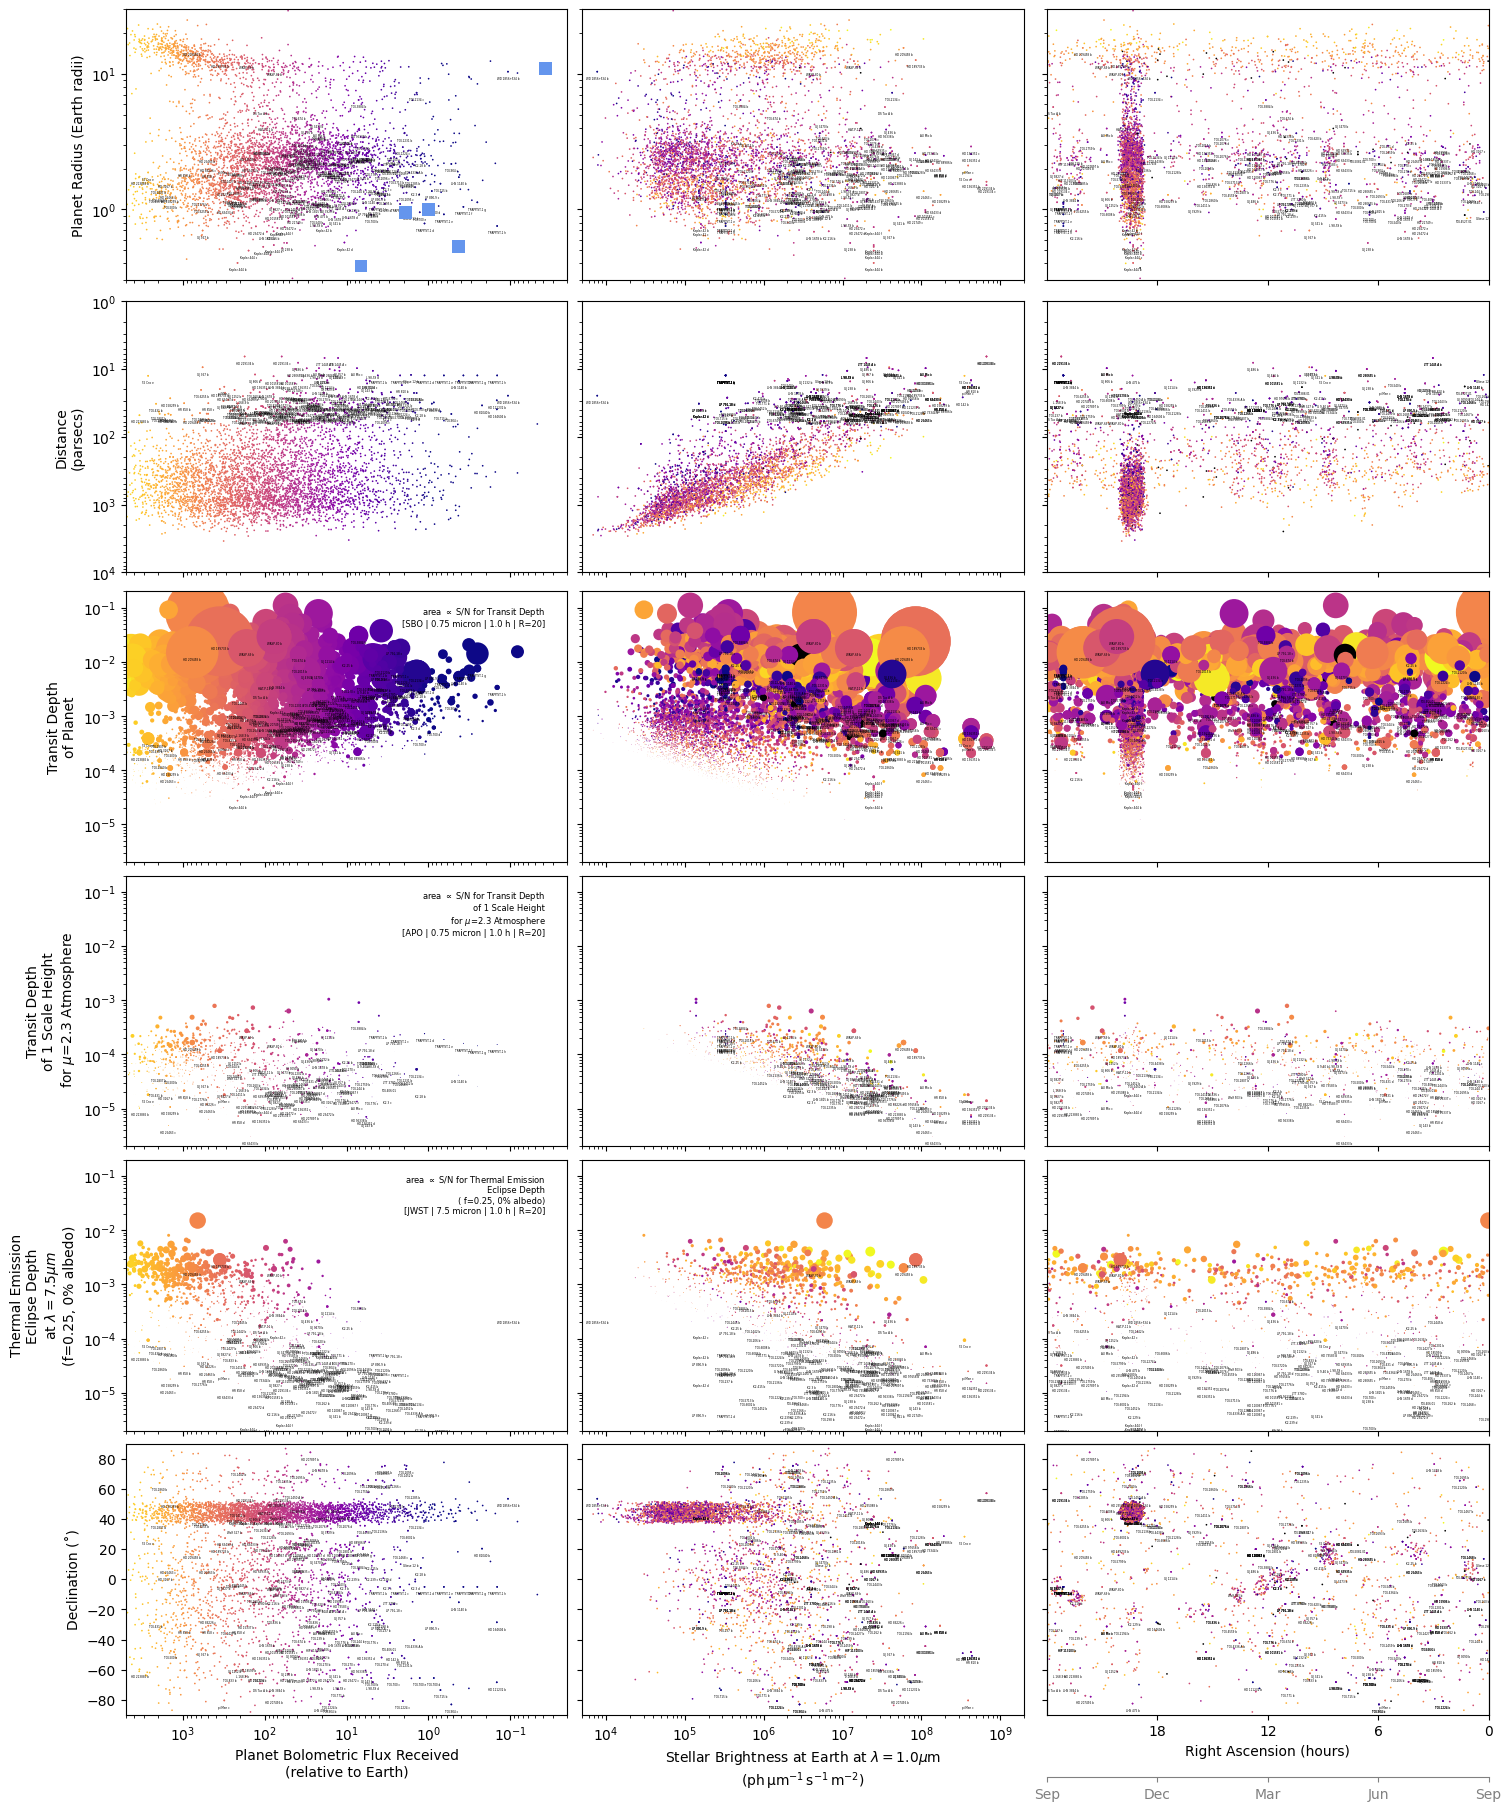

In [ ]:
grid = GridGallery(rows=[Radius(),
                  Distance(lim=[10000, 1]),
                  Depth(),
                  Transmission(), 
                  Emission(wavelength=7.5*u.micron),
                   Declination()], 
            cols=[Flux(lim=[0.5e4, 2e-2]), StellarBrightness(wavelength=1*u.micron, lim=[.5e4, 2e9]), RightAscension()])
snr_kw = dict(lim=[1, 1e2], scale='linear')
for k, m in grid.maps.items():
    if 'depth' in k:
        m.plottable['size'] = DepthSNR(telescope_name='SBO', wavelength=0.75*u.micron, **snr_kw)
    if 'transmission' in k:
        m.plottable['size'] = TransmissionSNR(telescope_name='APO', wavelength=0.75*u.micron, **snr_kw)
    if 'emission' in k: 
         m.plottable['size'] = EmissionSNR(telescope_name='JWST', wavelength=7.5*u.micron, **snr_kw)
    m.plottable['color'] = Flux(scale='log', lim=[1, 1e4])
    m.size_normalization = 4

to_annotate = e[e.distance() < 50*u.pc]
to_annotate.label = None 
to_annotate.annotate_planets = True
to_annotate.annotate_kw = dict(fontsize=2)
s = SolarSystem()
grid.build([s, e, to_annotate])
grid.maps['ra_x_dec'].ax.set_xticks([18,12,6,0])
RA_x_Dec.add_monthaxis(_, ax=grid.maps['ra_x_dec'].ax)

def add_size_explainer(ax=None, label='', x=.95, y=.95, ha='right', va='top', **kw):
    try:
        plt.sca(ax)
    except AttributeError:
        ax = plt.gca() 

    plt.text(x, y, f'area $\propto$ {label}', ha=ha, va=va, transform=ax.transAxes, **kw)

kw = dict(fontsize=6)
m = grid.maps['relative_insolation_x_transit_depth']
add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)

m = grid.maps['relative_insolation_x_transmission_signal']
add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)

m = grid.maps['relative_insolation_x_emission_signal']
add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)
plt.savefig('observers-guide-to-transiting-exoplanets.pdf')


Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-SolarSystem.txt


/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  sc

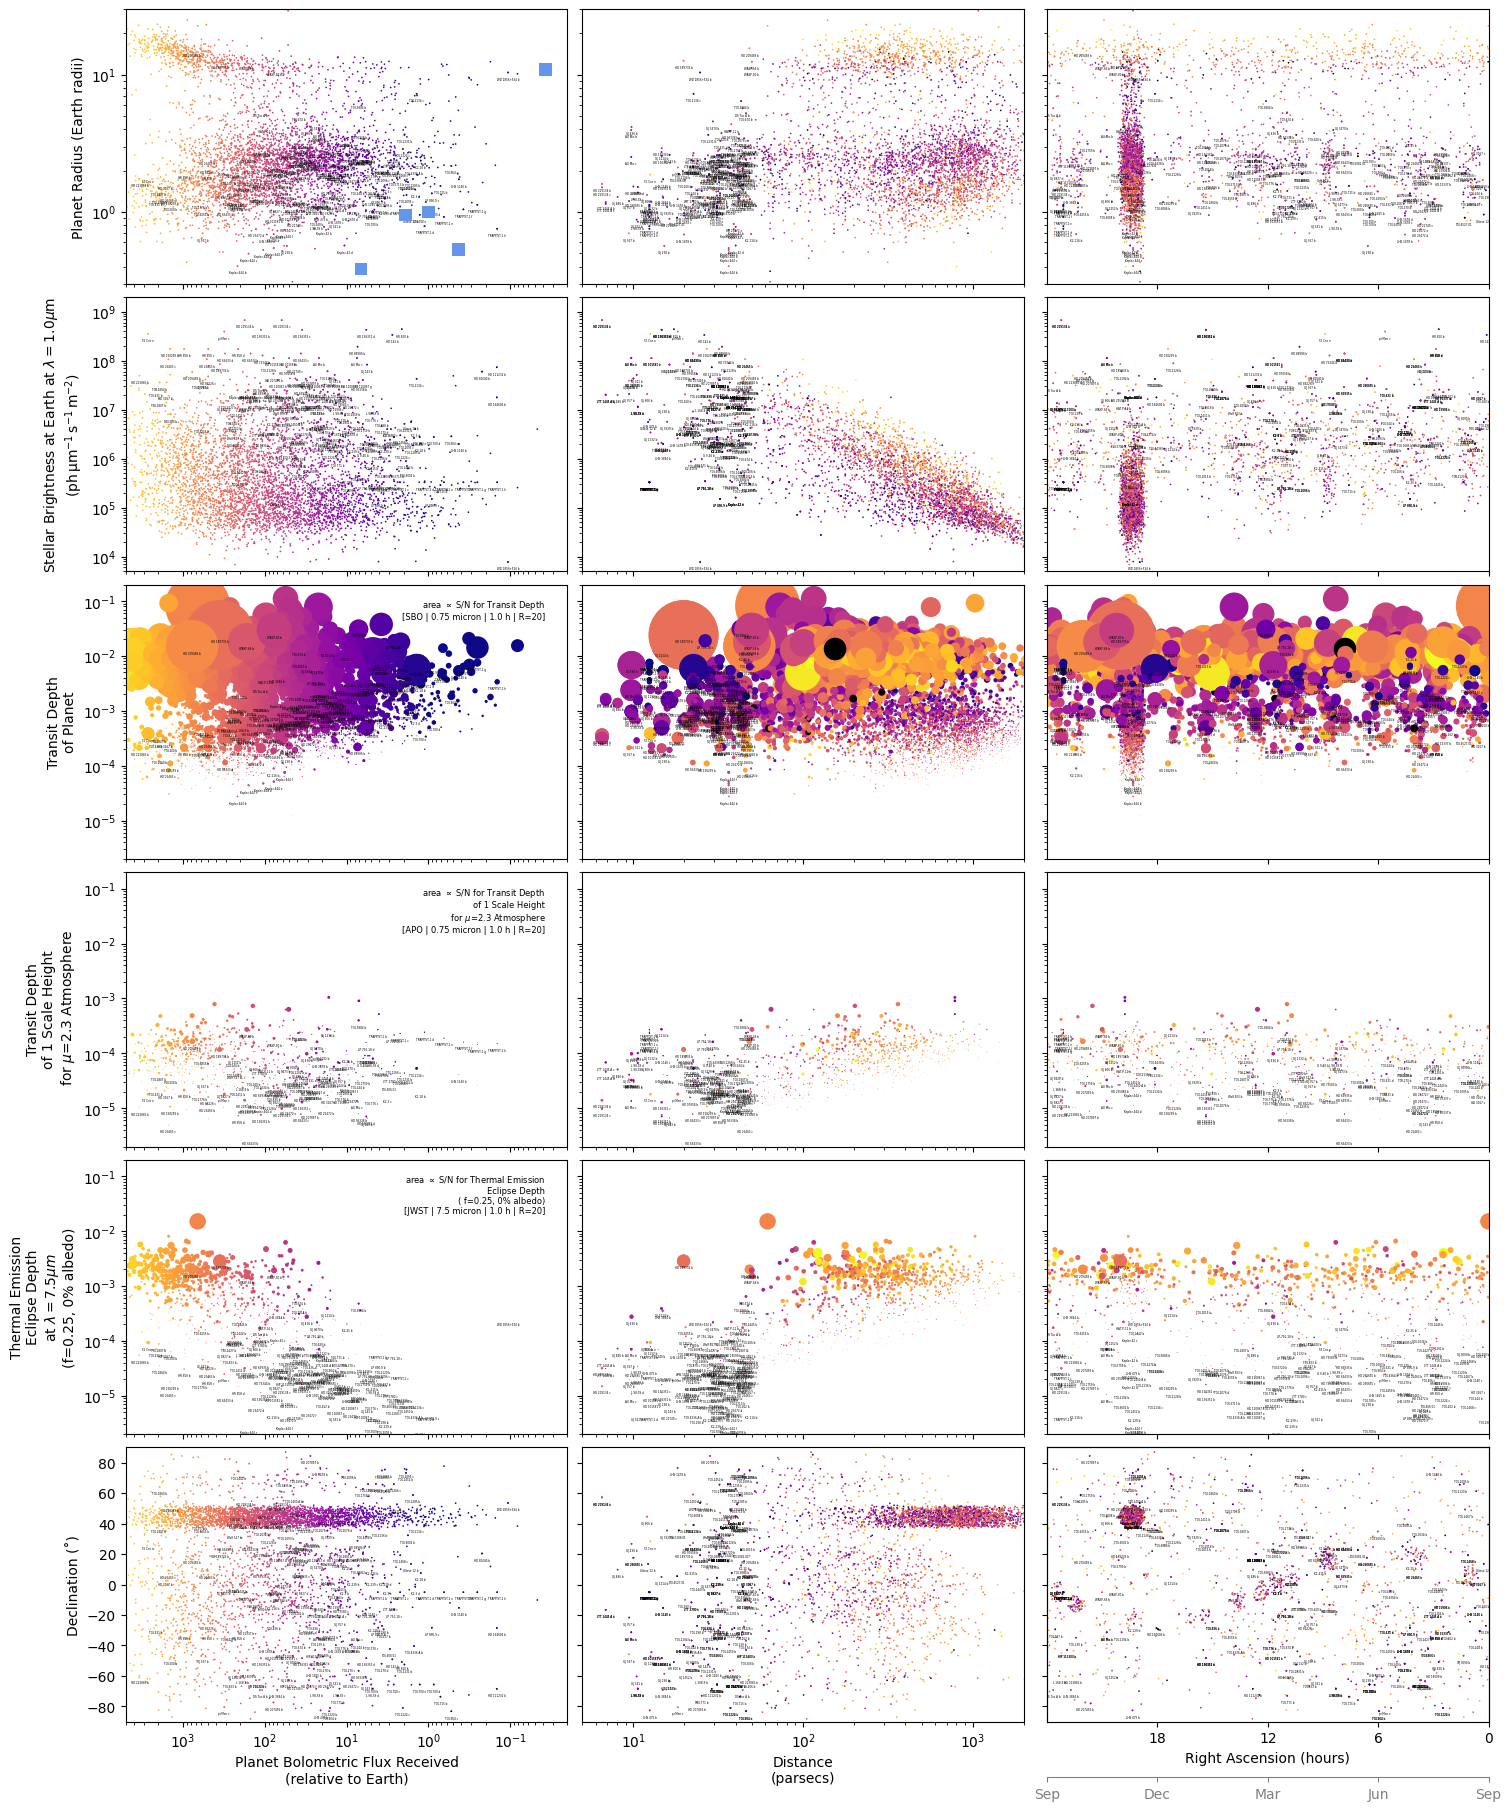

In [ ]:
grid = GridGallery(rows=[Radius(),
                   StellarBrightness(wavelength=1*u.micron, lim=[.5e4, 2e9]),
                   Depth(),
                  Transmission(), 
                  Emission(wavelength=7.5*u.micron),
                   Declination()], 
            cols=[Flux(lim=[0.5e4, 2e-2]), Distance(lim=[5, 2000]), RightAscension()])
snr_kw = dict(lim=[1, 1e2], scale='linear')
for k, m in grid.maps.items():
    if 'depth' in k:
        m.plottable['size'] = DepthSNR(telescope_name='SBO', wavelength=0.75*u.micron, **snr_kw)
    if 'transmission' in k:
        m.plottable['size'] = TransmissionSNR(telescope_name='APO', wavelength=0.75*u.micron, **snr_kw)
    if 'emission' in k: 
         m.plottable['size'] = EmissionSNR(telescope_name='JWST', wavelength=7.5*u.micron, **snr_kw)
    m.plottable['color'] = Flux(scale='log', lim=[1, 1e4])
    m.size_normalization = 4

to_annotate = e[e.distance() < 50*u.pc]
to_annotate.label = None 
to_annotate.annotate_planets = True
to_annotate.annotate_kw = dict(fontsize=2)
s = SolarSystem()
grid.build([s, e, to_annotate])
grid.maps['ra_x_dec'].ax.set_xticks([18,12,6,0])
RA_x_Dec.add_monthaxis(_, ax=grid.maps['ra_x_dec'].ax, position=40)

def add_size_explainer(ax=None, label='', x=.95, y=.95, ha='right', va='top', **kw):
    try:
        plt.sca(ax)
    except AttributeError:
        ax = plt.gca() 

    plt.text(x, y, f'area $\propto$ {label}', ha=ha, va=va, transform=ax.transAxes, **kw)

kw = dict(fontsize=6)
m = grid.maps['relative_insolation_x_transit_depth']
add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)

m = grid.maps['relative_insolation_x_transmission_signal']
add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)

m = grid.maps['relative_insolation_x_emission_signal']
add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)
plt.savefig('observers-guide-to-transiting-exoplanets.pdf')


Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-SolarSystem.txt


/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  sc

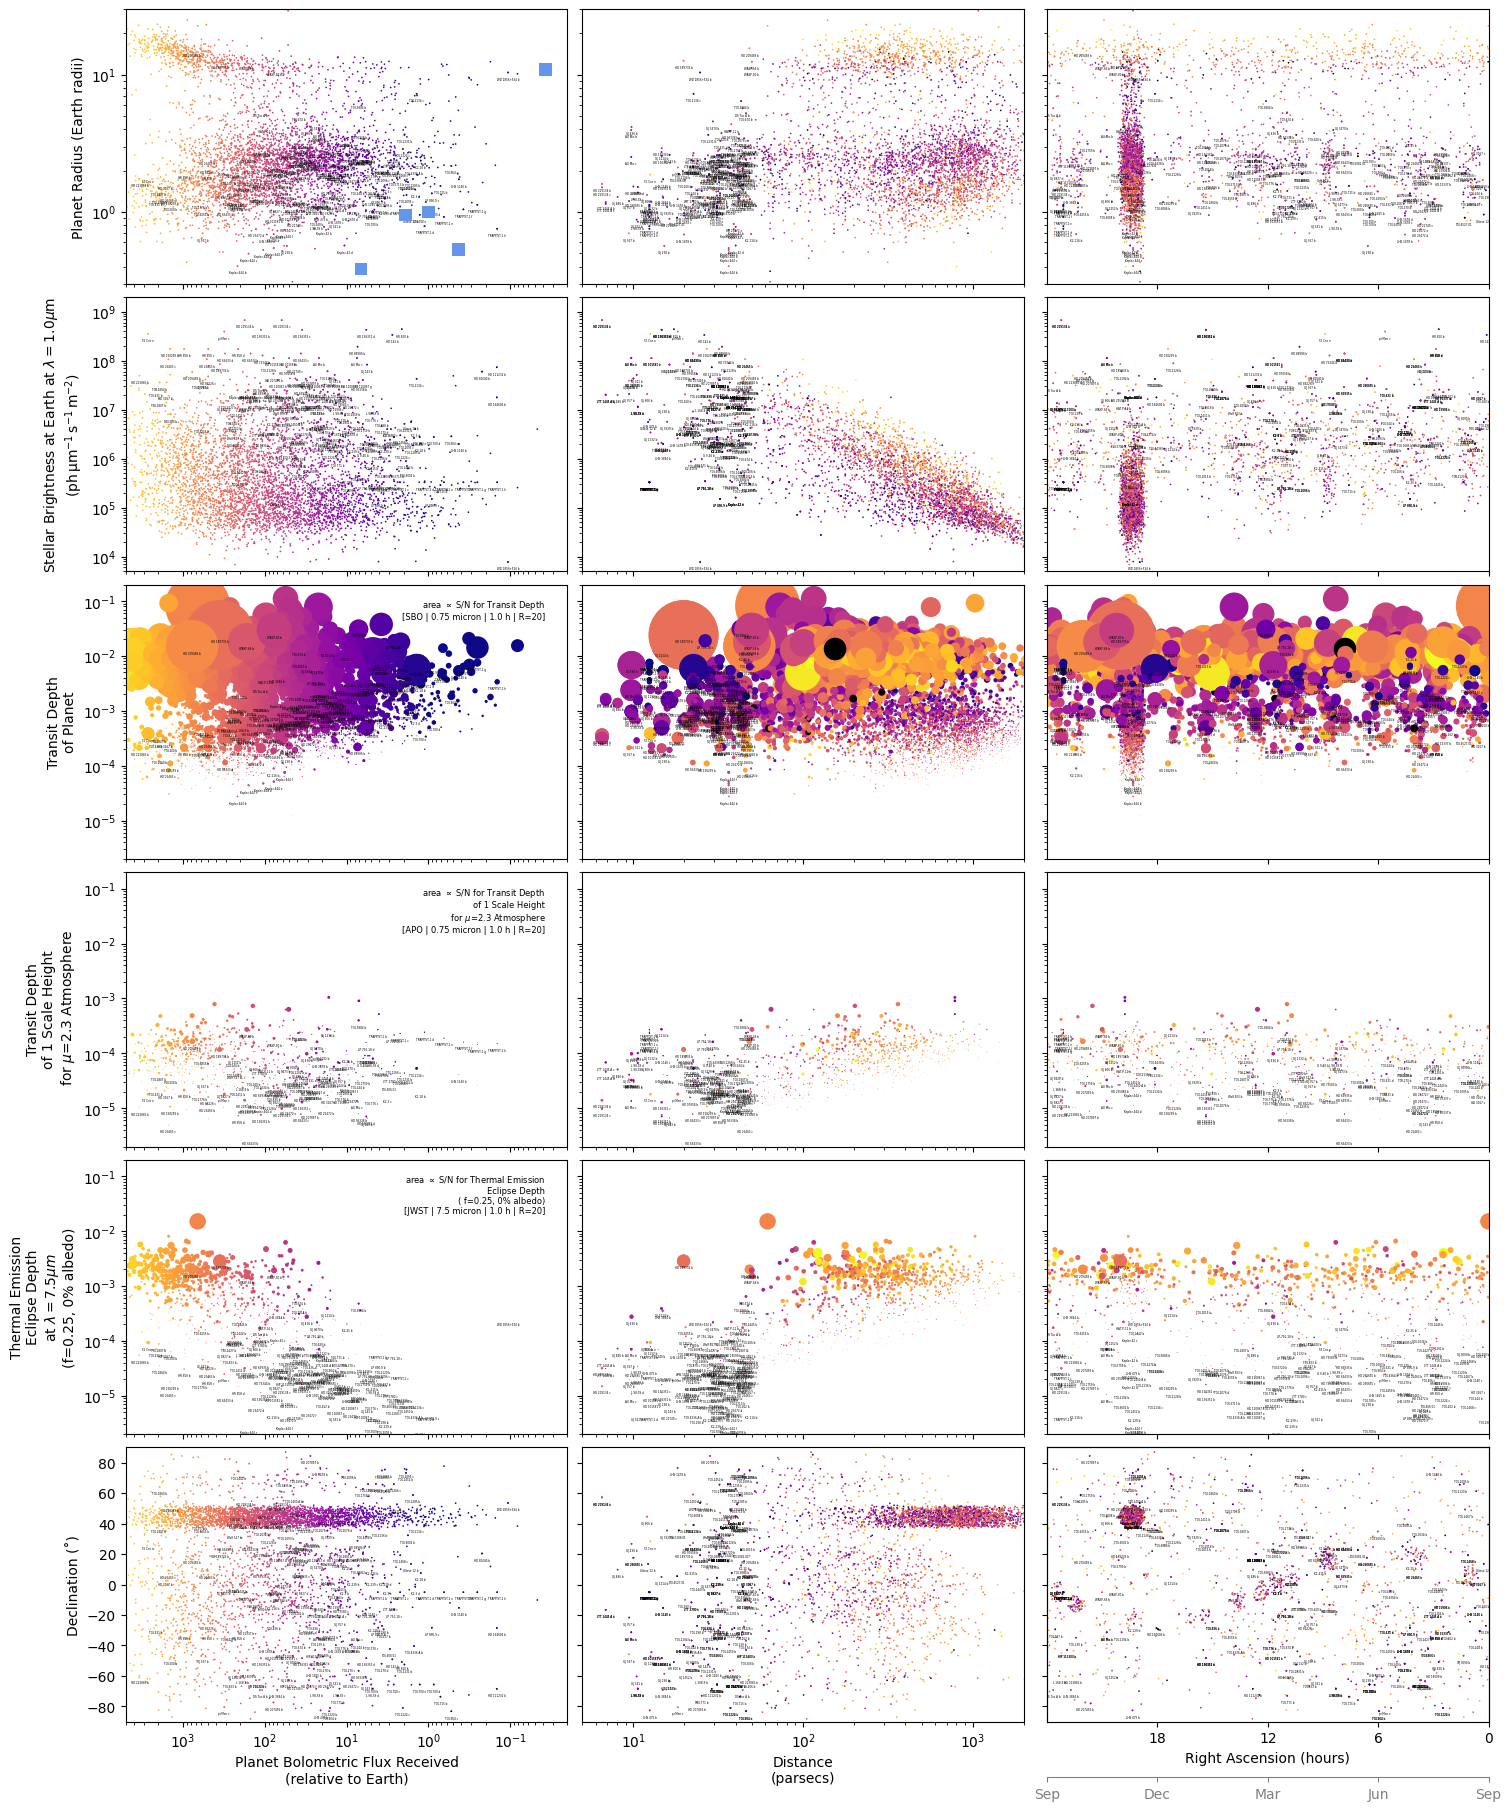

In [ ]:
def add_size_explainer(ax=None, label='', x=.95, y=.95, ha='right', va='top', **kw):
    try:
        plt.sca(ax)
    except AttributeError:
        ax = plt.gca() 

    plt.text(x, y, f'area $\propto$ {label}', ha=ha, va=va, transform=ax.transAxes, **kw)


class ObservableGallery(GridGallery):
    def __init__(self, **kw):
        GridGallery.__init__(self, rows=[Radius(),
                   StellarBrightness(wavelength=1*u.micron, lim=[.5e4, 2e9]),
                   Depth(),
                  Transmission(), 
                  Emission(wavelength=7.5*u.micron),
                   Declination()], 
            cols=[Flux(lim=[0.5e4, 2e-2]), Distance(lim=[5, 2000]), RightAscension()], **kw)

    def setup_maps(self, *args, **kw):
        GridGallery.setup_maps(self, *args, **kw)

        snr_kw = dict(lim=[1, 1e2], scale='linear')
        for k, m in self.maps.items():
            if 'depth' in k:
                m.plottable['size'] = DepthSNR(telescope_name='SBO', wavelength=0.75*u.micron, **snr_kw)
            if 'transmission' in k:
                m.plottable['size'] = TransmissionSNR(telescope_name='APO', wavelength=0.75*u.micron, **snr_kw)
            if 'emission' in k: 
                m.plottable['size'] = EmissionSNR(telescope_name='JWST', wavelength=7.5*u.micron, **snr_kw)
            m.plottable['color'] = Flux(scale='log', lim=[1, 1e4])
            m.size_normalization = 4

    def refine_maps(self):
        GridGallery.refine_maps(self)
        self.maps['ra_x_dec'].ax.set_xticks([18,12,6,0])
        RA_x_Dec.add_monthaxis(_, ax=self.maps['ra_x_dec'].ax, position=40)


        kw = dict(fontsize=6)
        m = self.maps['relative_insolation_x_transit_depth']
        add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)

        m = self.maps['relative_insolation_x_transmission_signal']
        add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)

        m = self.maps['relative_insolation_x_emission_signal']
        add_size_explainer(ax=m.ax, label=m.plottable['size'].label, **kw)


to_annotate = e[e.distance() < 50*u.pc]
to_annotate.label = None 
to_annotate.annotate_planets = True
to_annotate.annotate_kw = dict(fontsize=2)
s = SolarSystem()
obs = ObservableGallery()
obs.build([s, e, to_annotate])
#plt.savefig('observers-guide-to-transiting-exoplanets.pdf')



In [47]:
debug

> /Users/zabe0091/Dropbox/zach/code/exoatlas/exoatlas/visualizations/maps/Map.py(370)build()
    368 
    369         # loop over all the populations
--> 370         for key in self.populations.keys():
    371 
    372             # plot each population, passing plotting keywords to it



In [39]:
obs.build??

Signature: obs.build(pops, save=False, steps=True, format='png', savefig_kw={})
Source:   
    def build(self, pops, save=False, steps=True, format="png", savefig_kw={}):
        """
        Populate all Maps in a Gallery,
        using a set of populations.

        Parameters
        ----------
        pops : dict
            The populations to plot.
        save : bool
            Should we save the figure(s) to files?
        format : str
            What kind of graphics file should be saved?
            Any format allowed by `plt.savefig` is fine;
            we recommend `png` or `pdf`.
        savefig_kw : dict
            Keywords to pass to `plt.savefig` for saving figures.

        Returns
        -------
        self : Gallery
            In case you want to modify the plot after it's
            generated, this returns the entire Gallery.
        """

        # put data into the axes
        for k, p in self.maps.items():
            p.build(pops=pops, legend=False)

     

In [18]:
m = grid.maps['relative_insolation_x_transmission_signal']

In [11]:
grid.maps

{'relative_insolation_x_radius': 🖼️ BubbleMap
      x = 📏 relative_insolation
      y = 📏 radius
  color = 📏 relative_insolation,
 'stellar_brightness_x_radius': 🖼️ BubbleMap
      x = 📏 stellar_brightness
      y = 📏 radius
  color = 📏 relative_insolation,
 'ra_x_radius': 🖼️ BubbleMap
      x = 📏 ra
      y = 📏 radius
  color = 📏 relative_insolation,
 'relative_insolation_x_distance': 🖼️ BubbleMap
      x = 📏 relative_insolation
      y = 📏 distance
  color = 📏 relative_insolation,
 'stellar_brightness_x_distance': 🖼️ BubbleMap
      x = 📏 stellar_brightness
      y = 📏 distance
  color = 📏 relative_insolation,
 'ra_x_distance': 🖼️ BubbleMap
      x = 📏 ra
      y = 📏 distance
  color = 📏 relative_insolation,
 'relative_insolation_x_transit_depth': 🖼️ BubbleMap
      x = 📏 relative_insolation
      y = 📏 transit_depth
   size = 📏 depth_snr
  color = 📏 relative_insolation,
 'stellar_brightness_x_transit_depth': 🖼️ BubbleMap
      x = 📏 stellar_brightness
      y = 📏 transit_depth
   si

In [ ]:
def add_size_explainer(ax=None, label, x=.95, y=.95, ha='right', va='top', **kw):
    try:
        plt.sca(ax)
    except AttributeError:
        ax = plt.gca() 

    plt.text(x, y, f'area $\propto$ {label}', ha=ha, va=va, transform=ax.transAxes, **kw)


In [8]:
plt.sca(None)

AttributeError: 'NoneType' object has no attribute 'get_figure'